In [4]:
import numpy as np
import sympy as sp
import matplotlib as mp
import matplotlib.pyplot as plt


In [5]:
def CalculMat3D(N):
    # Create empty array
    A = np.zeros((N**3, N**3))
    h = 1/(N+1)
    # Cycling through each point in the array
    for i in range(N**3):
        for j in range(N**3):
            # Fill the diagonal with 4s
            if i == j:
                A[i,j] = 6/h**2
            # Fill the N diagonals with -1s for values above/below the 4s in the grid
            if i == j+N or i == j-N:
                A[i,j] = -1/h**2
            # Fill the +-1 diagonals with -1s
            if i == j+(N**2) or i == j-(N**2):
                A[i,j] = -1/h**2

            if i == j+1 or i == j-1:
                # // divides and rounds down.
                # This can be used such that any point along this diagonal where i is a different value to j will return 0
                if i // N == j // N: 
                    A[i,j] = -1/h**2
    return A

In [48]:
def CalculMat3D(N):
    # Create empty array
    A = sp.sparse.lil_matrix((N**3, N**3))
    h = 1/(N+1)
    # Cycling through each point in the array
    for i in range(N**3):
        for j in range(N**3):
            # Fill the diagonal with 4s
            if i == j:
                A[i,j] = 6/h**2
            # Fill the N diagonals with -1s for values above/below the 4s in the grid
            if i == j+N or i == j-N:
                A[i,j] = -1/h**2
            # Fill the +-1 diagonals with -1s
            if i == j+(N**2) or i == j-(N**2):
                A[i,j] = -1/h**2

            if i == j+1 or i == j-1:
                # // divides and rounds down.
                # This can be used such that any point along this diagonal where i is a different value to j will return 0
                if i // N == j // N: 
                    A[i,j] = -1/h**2
    return A

In [49]:
def I(i,j,k,n):
    return i + j*(n) +k*(n**2)

In [50]:
I(2,0,1,3)

11

In [51]:
def CalculRHS3D(N):
    Bh = np.zeros(N**3) 
    h = 1 / (N + 1)
    
    # Cycling through each point in the array
    for i in range(N):
        for j in range(N):
            for k in range(N):
                # Find value for point n in array Bh which is from the 2D coordinates k,j
                n = I(i, j, k, N)
                # Define x_j as given in the question
                x_j = (j+1) * h

                # To look at values that are only at the top of the grid (where the heat is being inputted)
                # This is the conditions for g(x)
                if (k+1) == N:
                    # Fill values in Bh with formula given for g(x)
                    Bh[n] = (x_j * (1 - x_j)) / h**2

    return Bh

In [52]:
n=10
Uh = np.linalg.solve(CalculMat3D(n), CalculRHS3D(n))

T = np.zeros((n, n, n))
for i in range(n):
    for j in range(n):
        for k in range(n):
                T[i, j, k] = Uh[I(j, i, k, n)]

AttributeError: module 'sympy' has no attribute 'sparse'

In [44]:
def slice(U, slice):
    plt.imshow(U[:,:, slice], origin = "lower")
    plt.show()


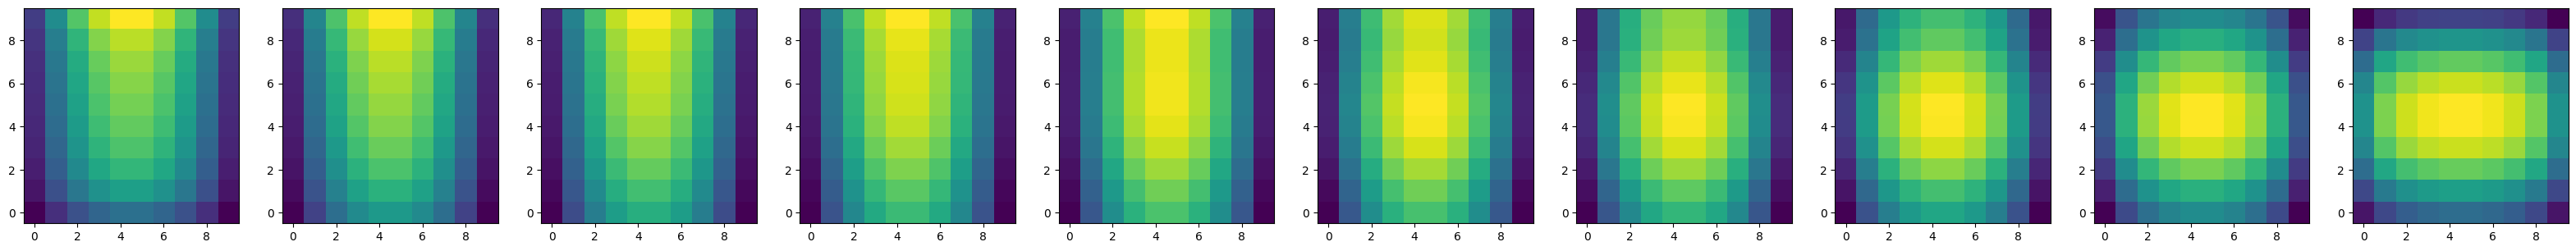

In [45]:
fig, axes = plt.subplots(1, n, figsize = (4*n, 4))
for i in range(n):
    axes[i].imshow(T[:,:, i], origin = "lower")


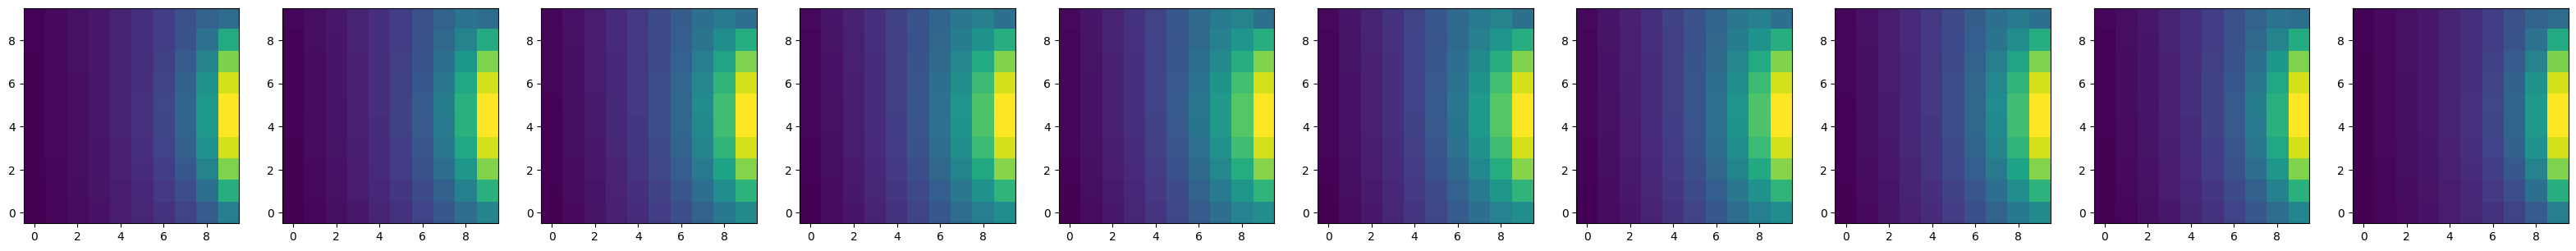

In [46]:
fig, axes = plt.subplots(1, n, figsize = (4*n, 4))
for i in range(n):
    axes[i].imshow(T[:,i, :], origin = "lower")

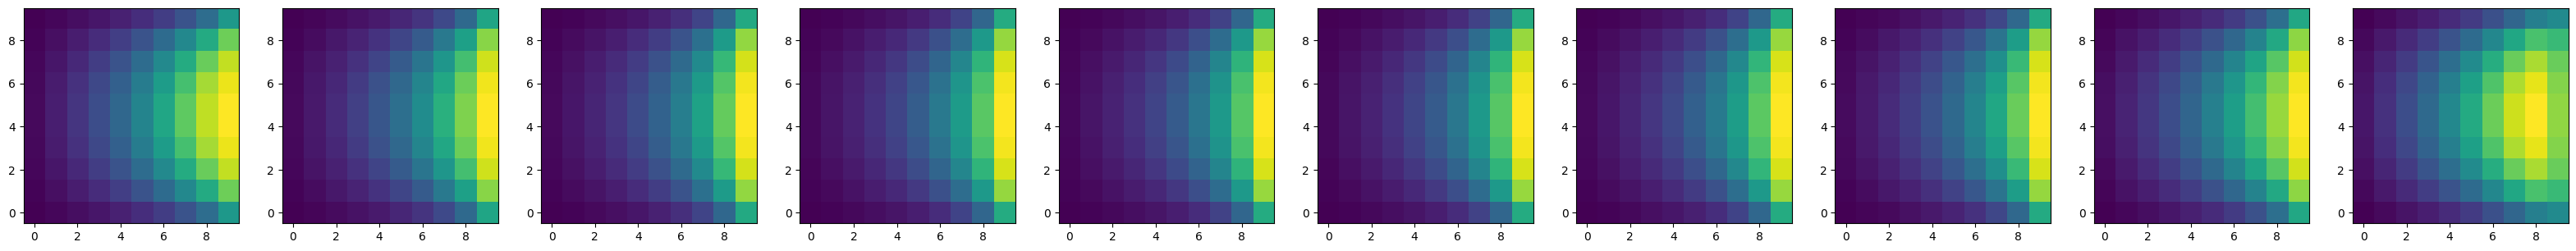

In [47]:
fig, axes = plt.subplots(1, n, figsize = (4*n, 4))
for i in range(n):
    axes[i].imshow(T[i,:,:], origin = "lower")